In [1]:
"""
TASK 3: BESS Sensitivity Analysis
============================================================
What this notebook is for: this notebook reuses the completed
solve_daily_qp() from Task 1 and sweeps the battery's hardware limits
(power rating and energy capacity) to see how they affect the optimal
schedule and the resulting 5-day electricity bill.

What you need to do in this notebook: type in the objective as what you have already completed in Task 1 objective.

Before you run this notebook, upload these two files to the Colab file
panel: perfect_load.csv and perfect_pv.csv (this notebook uses the same
base data as Task 1).
"""

import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pandas as pd

# ==============================================================================
# SECTION: Data loading helpers (no changes needed, same as Task 1)
# ==============================================================================
def read_load_generation(load_file, pv_file):
    df_load = pd.read_csv(load_file)
    df_pv = pd.read_csv(pv_file)

    dates = df_load.iloc[:, 0].astype(str).tolist()
    load_profiles = df_load.iloc[:, 1:].values.flatten()
    pv_profiles = df_pv.iloc[:, 1:].values.flatten()
    days = len(df_load)

    # Use 4-day load and generation data rather than 5-day data
    days = max(days - 1, 1)
    steps_per_day_local = df_load.shape[1] - 1  # number of readings per day: 48 steps
    dates = dates[:days]
    load_profiles = load_profiles[:days * steps_per_day_local]
    pv_profiles = pv_profiles[:days * steps_per_day_local]

    return load_profiles, pv_profiles, days, dates


def generate_eta_profiles(days, steps_per_day):
    eta_day = np.zeros(steps_per_day)
    eta_day[np.r_[0:14, 44:48]] = 0.03   # Off-peak rate ($/kWh)
    eta_day[np.r_[14:28, 40:44]] = 0.06  # Shoulder rate ($/kWh)
    eta_day[28:40]               = 0.30  # Peak rate ($/kWh)

    eta_profiles = np.tile(eta_day, days)
    return eta_profiles


# ==============================================================================
# SECTION: Core QP solver
# (This is the SAME objective you completed for Task 1. Type in the objective on your own.)
# ==============================================================================
def solve_daily_qp(p_load_day, p_pv_day, eta_day, z_init, steps_per_day, delta, p_min, p_max, c_max, w):
    x1 = cp.Variable(steps_per_day)  # BESS power
    x2 = cp.Variable(steps_per_day)  # Grid power
    z  = cp.Variable(steps_per_day + 1)  # BESS SOC (kWh)

    ### Completed Task 1 objective:
    objective = cp.Minimize(cp.sum(-delta * cp.multiply(eta_day, x1) + w * cp.multiply(eta_day, cp.square(x2))))

    # =========================================================================
    # SOC dynamics -- why the code indexing differs from the LaTeX
    # -------------------------------------------------------------------------
    # LaTeX (initial SoC z(0), interval index k = 1..s):
    #     z(k) = z(k-1) - delta * x1(k),        z(s) = z(0)      [Eqs. 15c, 15f]
    #
    # The code arrays are 0-based, and z carries ONE extra slot for z(0):
    #     z[0 .. s]     <->  z(0), z(1), ..., z(s)    (length s+1;  z[0] = z(0))
    #     x1[0 .. s-1]  <->  x1(1), x1(2), ..., x1(s) (length s;  there is no x1(0))
    #   =>  z[k] = z(k)   but   x1[k] = x1(k+1)
    #
    # Re-indexing the LaTeX recurrence to these 0-based arrays gives:
    #     z[k+1] = z[k] - delta * x1[k],        k = 0 .. s-1
    # It is the SAME equation -- the loop is just shifted so x1's index lines up
    # with k, which is why the range starts at 0 (not 1) and there is no x1[k-1].
    # =========================================================================
    constraints = [
        x2 == p_load_day - p_pv_day - x1,       # Power balance
        x1 >= p_min, x1 <= p_max,               # BESS power limits (swept in this notebook)
        z >= 0.0, z <= c_max,                    # BESS capacity boundaries (swept in this notebook)
        z[0] == z_init                          # z[0] = z(0): initial SoC (see indexing note above)
    ]

    for k in range(steps_per_day):            # k = 0..s-1 (0-based; see note above)
        constraints += [z[k+1] == z[k] - delta * x1[k]]

    constraints += [z[steps_per_day] == z[0]]   # cyclic: z(s) = z(0)

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)
    # Exclude z[0], the fixed initial-energy boundary, so the returned
    # energy trajectory has one end-of-interval value per dispatch step.
    return x1.value, x2.value, z.value[1:]


# ==============================================================================
# SECTION: Multi-day batch loop (no changes needed, same as Task 1)
# ==============================================================================
def run_batch_loop(global_z_init, days, steps_per_day, total_horizon, delta, load_profiles, pv_profiles, eta_profiles, p_min, p_max, c_max, w):
    all_x1_BESS = np.zeros(total_horizon)
    all_x2_grid = np.zeros(total_horizon)
    all_z_SOC   = np.zeros(total_horizon)

    current_z_init = global_z_init

    for d in range(days):
        start_idx = d * steps_per_day
        end_idx   = (d + 1) * steps_per_day

        p_load_day = load_profiles[start_idx:end_idx]
        p_pv_day   = pv_profiles[start_idx:end_idx]
        eta_day    = eta_profiles[start_idx:end_idx]

        x1_opt, x2_opt, z_opt = solve_daily_qp(
            p_load_day, p_pv_day, eta_day, current_z_init,
            steps_per_day, delta, p_min, p_max, c_max, w
        )

        all_x1_BESS[start_idx:end_idx] = x1_opt
        all_x2_grid[start_idx:end_idx] = x2_opt
        all_z_SOC[start_idx:end_idx]   = z_opt

        current_z_init = z_opt[-1]

    return all_x1_BESS, all_x2_grid, all_z_SOC


GROUP A: Fixed Capacity C = 13300 kWh, Varying Power P
Power Scale: 0.10x | P_max:   665.0 kW | Fixed C: 13300.0 kWh | Bill: $  5887.57
Power Scale: 0.15x | P_max:   997.5 kW | Fixed C: 13300.0 kWh | Bill: $  5056.45
Power Scale: 0.20x | P_max:  1330.0 kW | Fixed C: 13300.0 kWh | Bill: $  4626.47
Power Scale: 0.50x | P_max:  3325.0 kW | Fixed C: 13300.0 kWh | Bill: $  3732.46
Power Scale: 1.00x | P_max:  6650.0 kW | Fixed C: 13300.0 kWh | Bill: $  3732.46

GROUP B: Fixed Power P = 6650 kW, Varying Capacity C
Capacity Scale: 0.5x | C_max:    6650 kWh | Fixed P: 6650.0 kW | Bill: $  4821.04
Capacity Scale: 1.0x | C_max:   13300 kWh | Fixed P: 6650.0 kW | Bill: $  3732.46
Capacity Scale: 2.0x | C_max:   26600 kWh | Fixed P: 6650.0 kW | Bill: $  3443.48
Capacity Scale: 3.0x | C_max:   39900 kWh | Fixed P: 6650.0 kW | Bill: $  3331.19
Capacity Scale: 4.0x | C_max:   53200 kWh | Fixed P: 6650.0 kW | Bill: $  3331.19


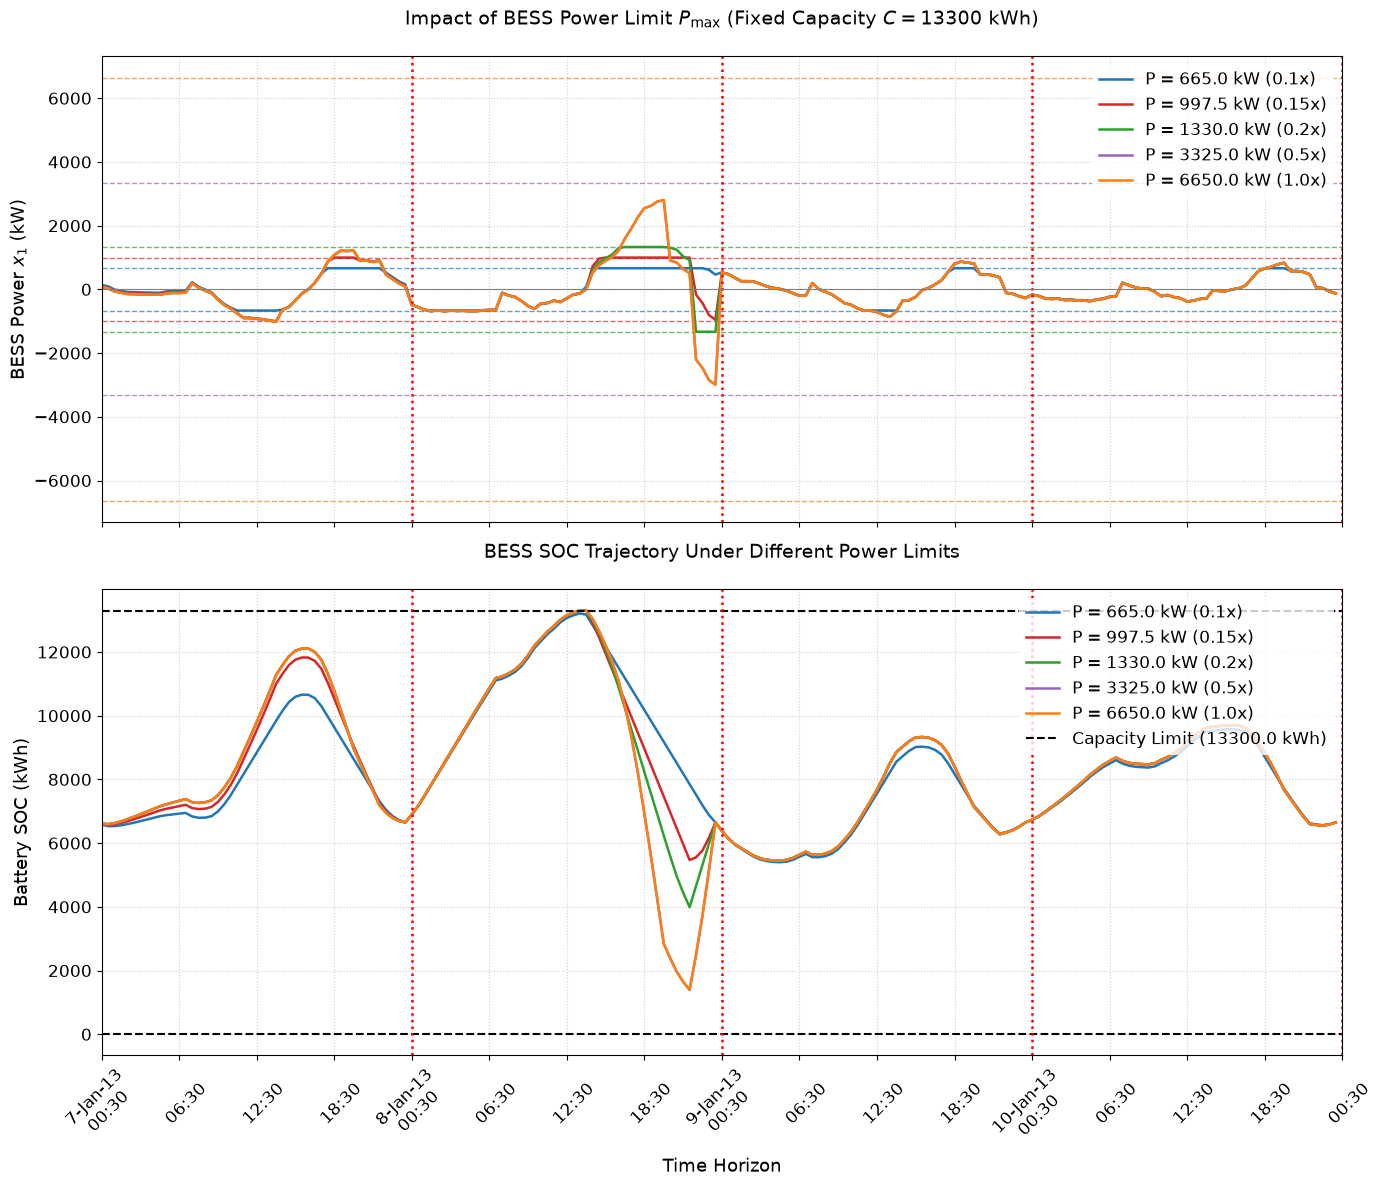

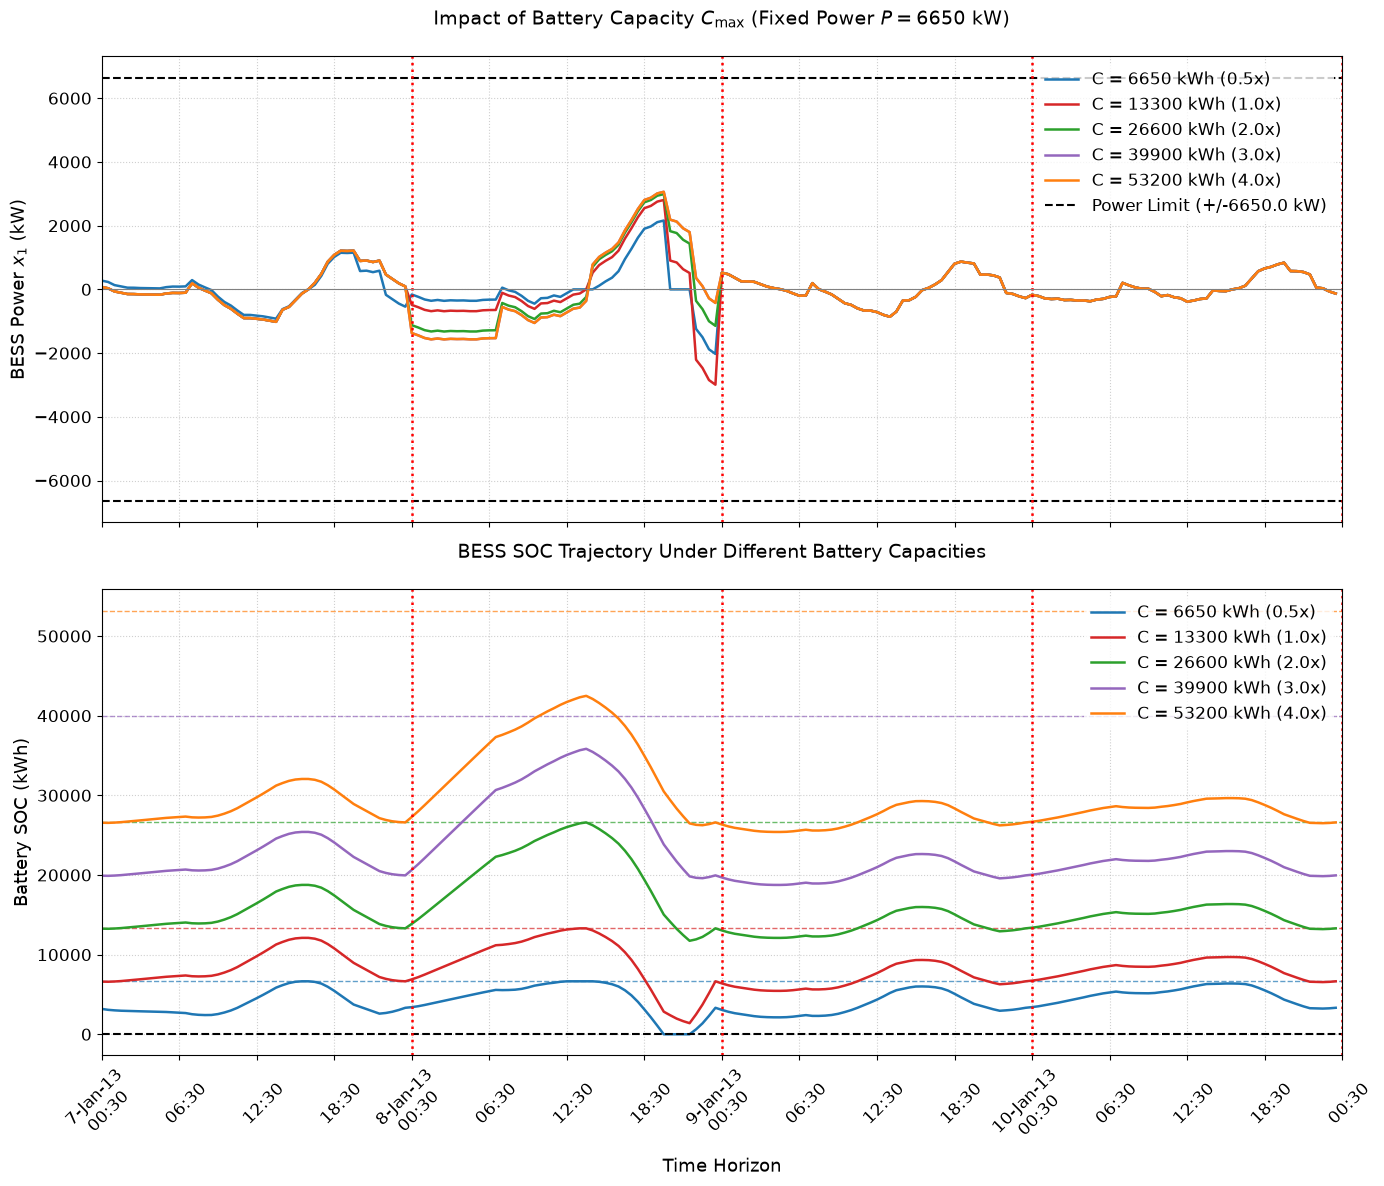

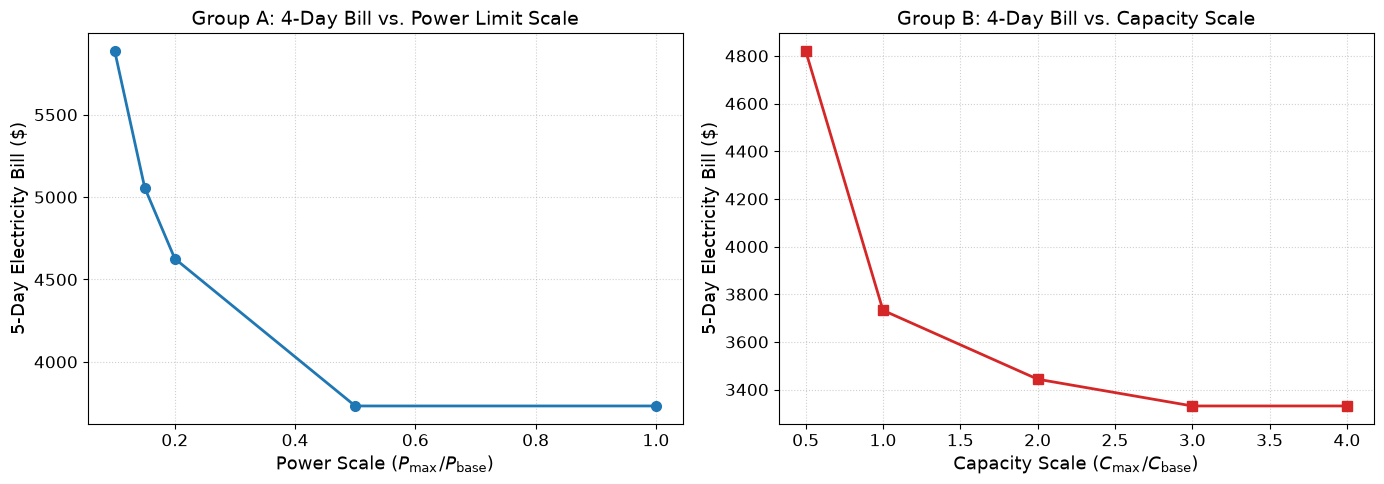

In [2]:
"""
MAIN EXECUTION: Sensitivity Sweep
============================================================
No changes needed -- just run this cell. It will:
  1. Group A: fix the battery capacity and sweep the power limit P_max
     across [0.1, 0.15, 0.2, 0.5, 1.0] x P_base, solving the full 5-day QP
     for each value and recording the resulting bill.
  2. Group B: fix the power limit and sweep the capacity C_max across
     [0.5, 1.0, 2.0, 3.0, 4.0] x C_base, again recording the resulting bill.
  3. Plot the BESS power and SOC trajectories overlaid for each group.
  4. Plot the 5-day electricity bill against battery size for both
     groups, so the diminishing-returns pattern is visible directly.
"""

steps_per_day = 48
delta = 0.5
w = 1.0

load_csv_path = 'perfect_load.csv'
pv_csv_path = 'perfect_pv.csv'
load_profiles, pv_profiles, days, dates = read_load_generation(load_csv_path, pv_csv_path)

total_horizon = days * steps_per_day
eta_profiles = generate_eta_profiles(days, steps_per_day)

### Base (nominal) hardware parameters -- do not change
total_customers = 1330
base_p_max = 5.0 * total_customers      # 6650 kW
base_c_max = 10.0 * total_customers     # 13300 kWh

time_steps = np.arange(total_horizon)
timeline_hours = time_steps * delta

### Scale factors applied to the base parameters for each sweep
p_scales = [0.1, 0.15, 0.2, 0.5, 1.0]
c_scales = [0.5, 1.0, 2.0, 3.0, 4.0]

# ------------------------------------------------------------------------------
# Group A: Fixed Capacity C_max = 13300 kWh, Varying Power P_max
# ------------------------------------------------------------------------------
print("=" * 65)
print("GROUP A: Fixed Capacity C = 13300 kWh, Varying Power P")
print("=" * 65)

results_GroupA = {}

for s in p_scales:
    c_max_test = base_c_max
    p_max_test = base_p_max * s
    p_min_test = -p_max_test
    z_init_test = 0.5 * c_max_test

    x1, x2, z = run_batch_loop(
        z_init_test, days, steps_per_day, total_horizon, delta,
        load_profiles, pv_profiles, eta_profiles,
        p_min_test, p_max_test, c_max_test, w
    )
    bill = np.sum(eta_profiles * x2 * delta)

    results_GroupA[f"P = {p_max_test:.1f} kW ({s}x)"] = {
        'x1': x1, 'z': z, 'bill': bill, 'p_max': p_max_test, 'c_max': c_max_test, 'scale': s
    }
    print(f"Power Scale: {s:4.2f}x | P_max: {p_max_test:7.1f} kW | Fixed C: {c_max_test} kWh | Bill: ${bill:9.2f}")

# ------------------------------------------------------------------------------
# Group B: Fixed Power P_max = 6650 kW, Varying Capacity C_max
# ------------------------------------------------------------------------------
print("\n" + "=" * 65)
print("GROUP B: Fixed Power P = 6650 kW, Varying Capacity C")
print("=" * 65)

results_GroupB = {}

for s in c_scales:
    c_max_test = base_c_max * s
    p_max_test = base_p_max
    p_min_test = -p_max_test
    z_init_test = 0.5 * c_max_test

    x1, x2, z = run_batch_loop(
        z_init_test, days, steps_per_day, total_horizon, delta,
        load_profiles, pv_profiles, eta_profiles,
        p_min_test, p_max_test, c_max_test, w
    )
    bill = np.sum(eta_profiles * x2 * delta)

    results_GroupB[f"C = {int(c_max_test)} kWh ({s}x)"] = {
        'x1': x1, 'z': z, 'bill': bill, 'p_max': p_max_test, 'c_max': c_max_test, 'scale': s
    }
    print(f"Capacity Scale: {s:3.1f}x | C_max: {c_max_test:7.0f} kWh | Fixed P: {p_max_test} kW | Bill: ${bill:9.2f}")

print("=" * 65)

# ==============================================================================
# Visualizations
# ==============================================================================

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'savefig.dpi': 300
})

total_hours = timeline_hours[-1] + delta
tick_hours = np.arange(0, total_hours + 1, 6)

time_labels = []
for h in tick_hours:
    day_idx = int(h // 24)
    time_str = f"{int(h % 24):02d}:30"

    if h % 24 == 0 and day_idx < days:
        time_labels.append(f"{dates[day_idx]}\n{time_str}")
    else:
        time_labels.append(f"\n{time_str}")


high_contrast_colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e']


### ------------------------------------------------------------------------------
### Figure 1: Group A - Varying Power P (Fixed C = 13300 kWh)
### ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

for idx, (label, res) in enumerate(results_GroupA.items()):
    c = high_contrast_colors[idx]
    # Continuous curves
    ax1.plot(timeline_hours, res['x1'], color=c, label=f"{label}", linewidth=1.8)
    ax2.plot(timeline_hours, res['z'], color=c, label=label, linewidth=1.8)

    # Dashed lines for individual power limits
    ax1.axhline(res['p_max'], color=c, linestyle='--', linewidth=1.0, alpha=0.7)
    ax1.axhline(-res['p_max'], color=c, linestyle='--', linewidth=1.0, alpha=0.7)

# Fixed Capacity bounds for SOC
ax2.axhline(base_c_max, color='black', linestyle='--', linewidth=1.5, label=f"Capacity Limit ({base_c_max} kWh)")
ax2.axhline(0, color='black', linestyle='--', linewidth=1.5)

# Day boundary lines
for d in range(1, days + 1):
    ax1.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=1.8)
    ax2.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=1.8)

ax1.set_title('Impact of BESS Power Limit $P_{\\text{max}}$ (Fixed Capacity $C = 13300$ kWh)', y=1.05)
ax1.set_ylabel('BESS Power $x_1$ (kW)')
ax1.axhline(0, color='gray', linestyle='-', linewidth=0.8)
ax1.set_xlim(0, total_hours)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

ax2.set_title('BESS SOC Trajectory Under Different Power Limits', y=1.05)
ax2.set_ylabel('Battery SOC (kWh)')
ax2.set_xlabel('Time Horizon')
ax2.set_xlim(0, total_hours)
ax2.set_xticks(tick_hours)
ax2.set_xticklabels(time_labels, rotation=45)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()


### ------------------------------------------------------------------------------
### Figure 2: Group B - Varying Capacity C (Fixed P = 6650 kW)
### ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

for idx, (label, res) in enumerate(results_GroupB.items()):
    c = high_contrast_colors[idx]
    # Continuous curves
    ax1.plot(timeline_hours, res['x1'], color=c, label=f"{label}", linewidth=1.8)
    ax2.plot(timeline_hours, res['z'], color=c, label=label, linewidth=1.8)

    # Dashed lines for individual capacity limits
    ax2.axhline(res['c_max'], color=c, linestyle='--', linewidth=1.0, alpha=0.7)

# Fixed Power bounds for x1
ax1.axhline(base_p_max, color='black', linestyle='--', linewidth=1.5, label=f"Power Limit (+/-{base_p_max} kW)")
ax1.axhline(-base_p_max, color='black', linestyle='--', linewidth=1.5)
ax2.axhline(0, color='black', linestyle='--', linewidth=1.5)

# Day boundary lines
for d in range(1, days + 1):
    ax1.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=1.8)
    ax2.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=1.8)

ax1.set_title('Impact of Battery Capacity $C_{\\text{max}}$ (Fixed Power $P = 6650$ kW)', y=1.05)
ax1.set_ylabel('BESS Power $x_1$ (kW)')
ax1.axhline(0, color='gray', linestyle='-', linewidth=0.8)
ax1.set_xlim(0, total_hours)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

ax2.set_title('BESS SOC Trajectory Under Different Battery Capacities', y=1.05)
ax2.set_ylabel('Battery SOC (kWh)')
ax2.set_xlabel('Time Horizon')
ax2.set_xlim(0, total_hours)
ax2.set_xticks(tick_hours)
ax2.set_xticklabels(time_labels, rotation=45)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()


### ==============================================================================
### Figure 3 (NEW): 5-day electricity bill vs. battery size
### This directly visualizes the diminishing-returns pattern needed for
### Task 3 and the grade sheet questions on bill-vs-size.
### ==============================================================================
scalesA = [res['scale'] for res in results_GroupA.values()]
billsA  = [res['bill']  for res in results_GroupA.values()]

scalesB = [res['scale'] for res in results_GroupB.values()]
billsB  = [res['bill']  for res in results_GroupB.values()]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))

axA.plot(scalesA, billsA, 'o-', color='#1f77b4', linewidth=2.0, markersize=7)
axA.set_title('Group A: 4-Day Bill vs. Power Limit Scale')
axA.set_xlabel('Power Scale ($P_{\\max} / P_{\\text{base}}$)')
axA.set_ylabel('5-Day Electricity Bill ($)')
axA.grid(True, linestyle=':', alpha=0.6)

axB.plot(scalesB, billsB, 's-', color='#d62728', linewidth=2.0, markersize=7)
axB.set_title('Group B: 4-Day Bill vs. Capacity Scale')
axB.set_xlabel('Capacity Scale ($C_{\\max} / C_{\\text{base}}$)')
axB.set_ylabel('5-Day Electricity Bill ($)')
axB.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('task3_bill_vs_size.png', dpi=300)
plt.show()
